# 1. CHURN PREDICTION

# IMPORT LIBRARIES.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# LOAD THE DATASET.

In [2]:
file_path = ("/kaggle/input/datasets/chetanmittal033/bank-dataset-for-customer-churn-prediction/Churn_Modelling.csv")
df = pd.read_csv(file_path)
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# DATA CLEANING.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [6]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# DATA VISUALIZATION.

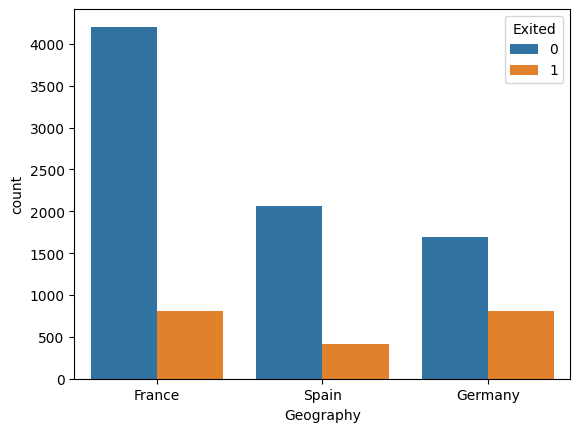

In [7]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

The plot shows how customer churn varies across different geographical regions.
It indicates that certain regions have a higher churn rate, suggesting location influences customer behavior.

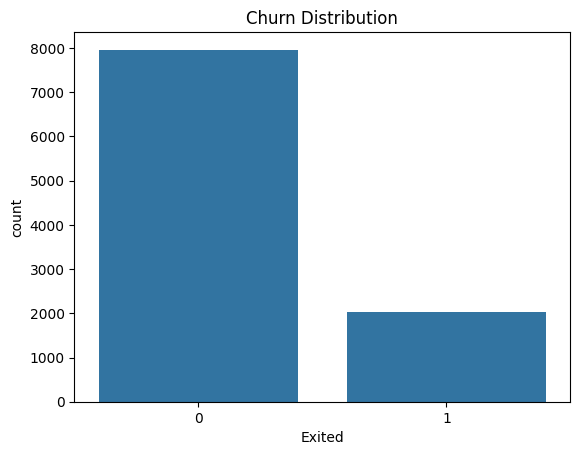

In [8]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

“The countplot shows that the number of non-churn customers (0) is higher than churn customers (1), indicating that the dataset is imbalanced. This imbalance can affect model performance.”

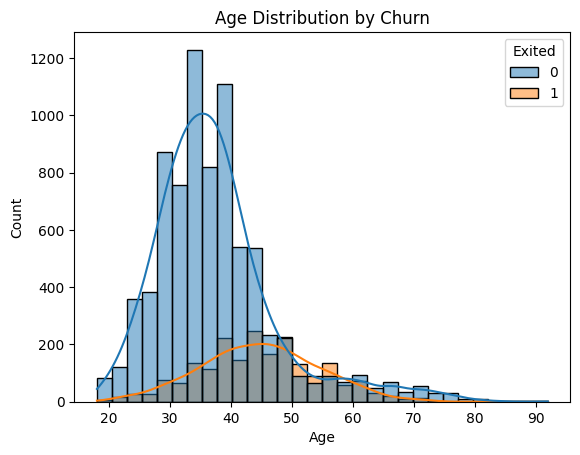

In [9]:

sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True)
plt.title("Age Distribution by Churn")
plt.show()

The plot shows how customer age is distributed across churn and non-churn groups, highlighting differences in churn behavior by age.

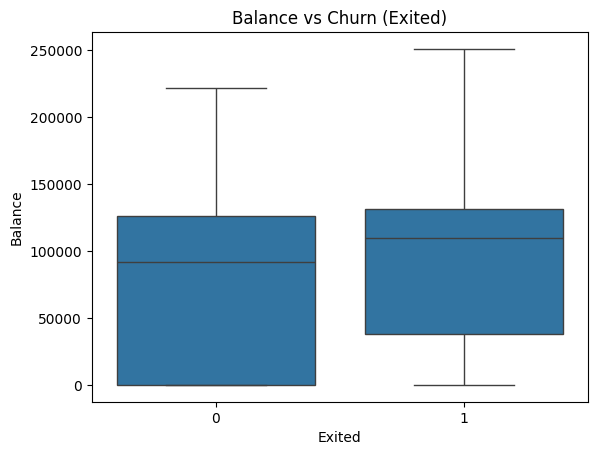

In [10]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn (Exited)")
plt.show()

Higher median account balances are observed among churned customers compared to those who stayed, indicating that customers with more funds are more likely to exit.

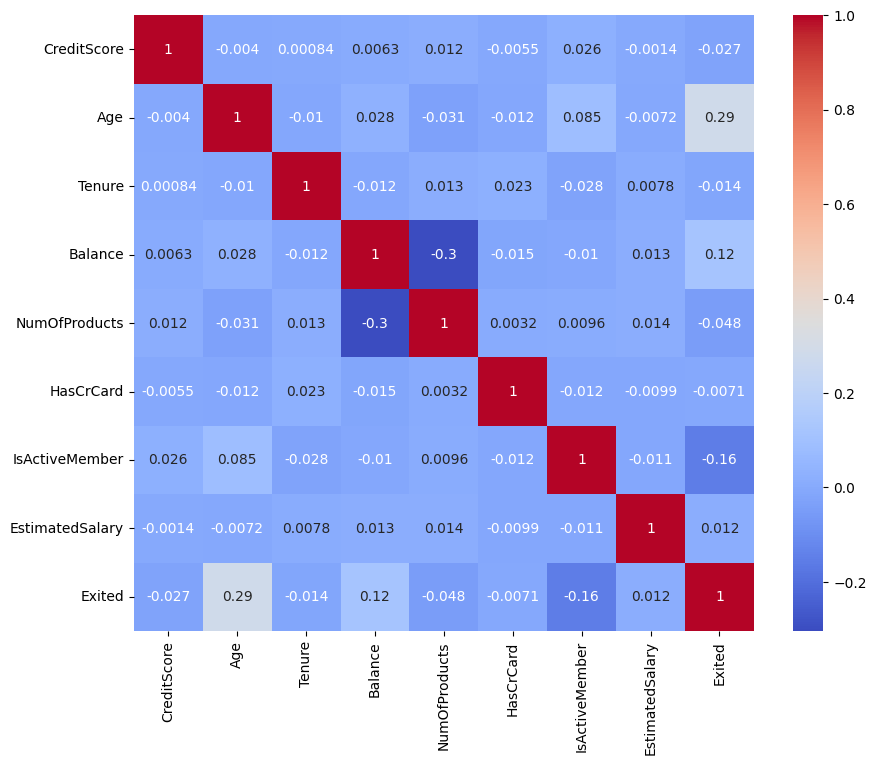

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.show()

The correlation heatmap shows that Age has the strongest positive relationship with churn, meaning older customers are more likely to exit. Other features like Balance show a weak positive connection, while IsActiveMember has a negative correlation, indicating active users are less likely to leave.

# DATA PREPROCESSING.

In [12]:
cat_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [13]:
df.astype(int)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,0,1
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,0,1


In [14]:
TARGET_COL = 'Exited'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [15]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [16]:
df_scaled

array([[-0.32622142,  0.29351742, -1.04175968, ..., -0.57873591,
        -0.57380915, -1.09598752],
       [-0.44003595,  0.19816383, -1.38753759, ..., -0.57873591,
         1.74273971, -1.09598752],
       [-1.53679418,  0.29351742,  1.03290776, ..., -0.57873591,
        -0.57380915, -1.09598752],
       ...,
       [ 0.60498839, -0.27860412,  0.68712986, ..., -0.57873591,
        -0.57380915, -1.09598752],
       [ 1.25683526,  0.29351742, -0.69598177, ...,  1.72790383,
        -0.57380915,  0.91241915],
       [ 1.46377078, -1.04143285, -0.35020386, ..., -0.57873591,
        -0.57380915, -1.09598752]])

# TRAIN TEST SPLIT.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # maintains class distribution
)

# -------------------------------
# Inspect first few rows
# -------------------------------
print("X_train head:\n", X_train.head())
print("\ny_train first 5 values:\n", y_train[:5])

X_train head:
       CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
2151          753   57       7       0.00              1          1   
8392          739   32       3  102128.27              1          1   
5006          755   37       0  113865.23              2          1   
4117          561   37       5       0.00              2          1   
7182          692   49       6  110540.43              2          0   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
2151               0        159475.08              False            False   
8392               0         63981.37               True            False   
5006               1        117396.25               True            False   
4117               0         83093.25              False            False   
7182               1        107472.99               True            False   

      Gender_Male  
2151         True  
8392         True  
5006        False  
4117         Tr

# MODEL TRAINING.

In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

# EVALUATION.

In [19]:
y_pred = model.predict(X_test)
print('test result given data: ', y_test)
print('test result predicted data', y_pred)

test result given data:  5702    0
3667    0
1617    0
5673    0
4272    0
       ..
5768    0
833     0
9719    1
2776    0
3776    0
Name: Exited, Length: 2000, dtype: int64
test result predicted data [0 0 0 ... 1 0 0]


In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8605
Confusion Matrix:
 [[1542   51]
 [ 228  179]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [21]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.3).astype(int)

In [22]:
RandomForestClassifier(class_weight='balanced')

RandomForestClassifier(class_weight='balanced')

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



The model is performing with 76% overall accuracy and shows a balanced performance between both classes. The recall for the churn class (1) has improved to 0.66, meaning it is now detecting more customers who are likely to leave.

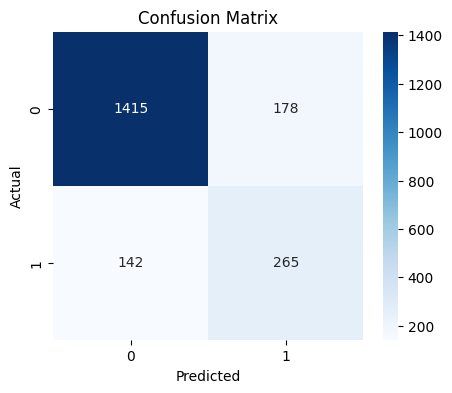

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

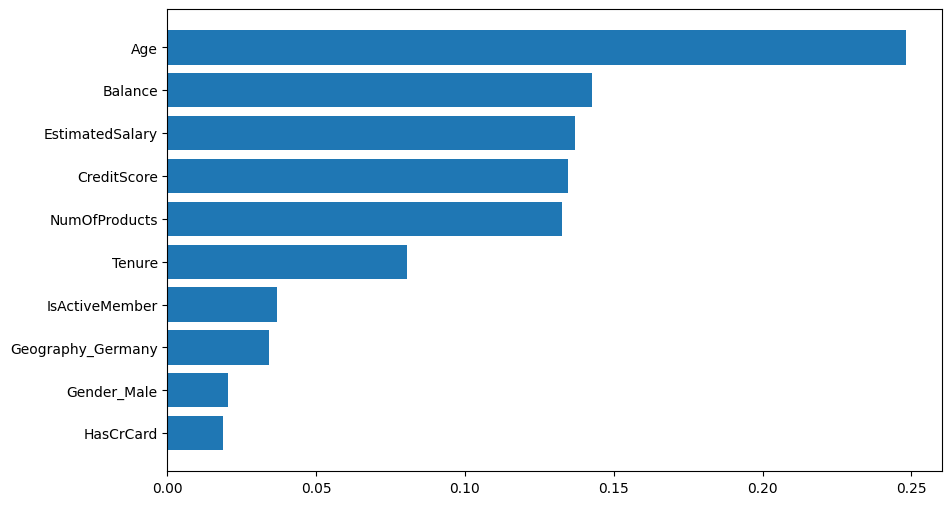

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.show()

# 2. SALES FORCASTING..

# IMORT LIBRARIES.

In [26]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# DATA LOADING.

In [27]:
file_path = ("/kaggle/input/datasets/muharremg/dataset-demand-forcasting/train.csv")
df_2 = pd.read_csv(file_path)
df_2

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


# DATA CLEANING.

In [28]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [29]:
df_2.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [30]:
df_2.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
912995    False
912996    False
912997    False
912998    False
912999    False
Length: 913000, dtype: bool

In [31]:
df_2['date'] = pd.to_datetime(df_2['date'])

In [32]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


# DATA VISUALIZATION.

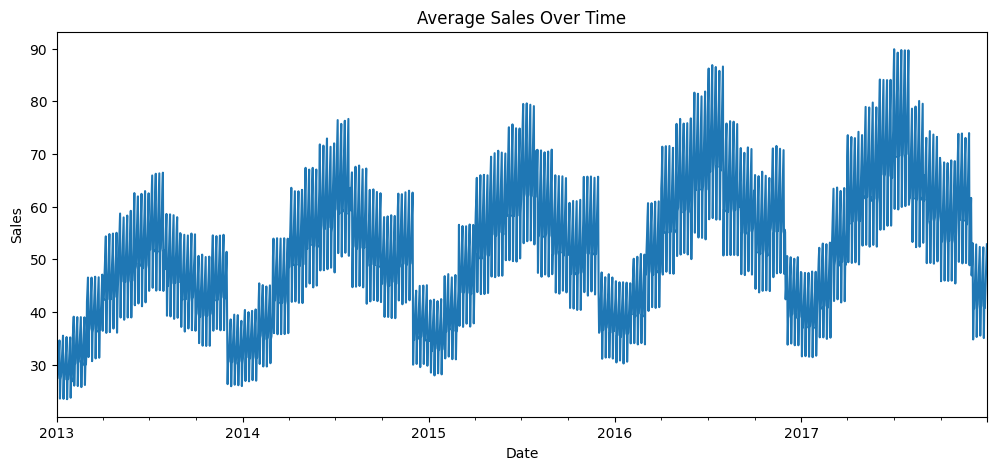

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

df_2.groupby('date')['sales'].mean().plot(figsize=(12,5))
plt.title("Average Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

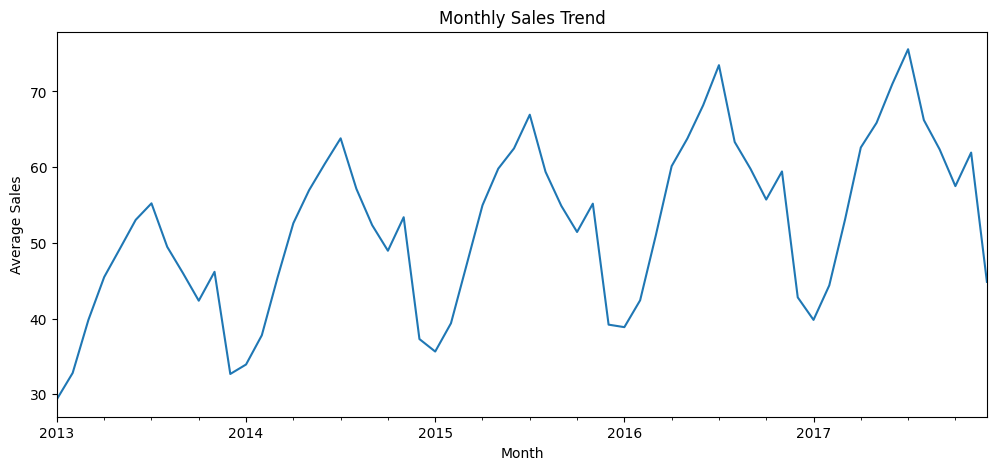

In [34]:
df_monthly = df_2.set_index('date').resample('ME')['sales'].mean()

df_monthly.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

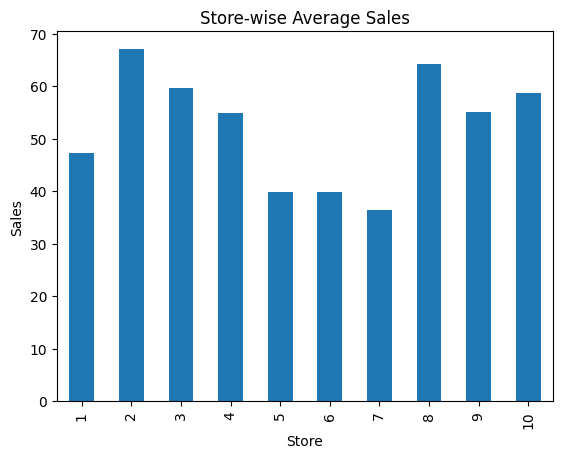

In [35]:
df_2.groupby('store')['sales'].mean().plot(kind='bar')
plt.title("Store-wise Average Sales")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

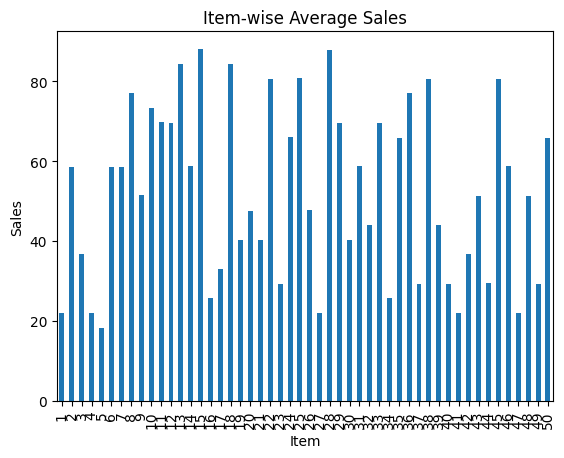

In [36]:
df_2.groupby('item')['sales'].mean().plot(kind='bar')
plt.title("Item-wise Average Sales")
plt.xlabel("Item")
plt.ylabel("Sales")
plt.show()

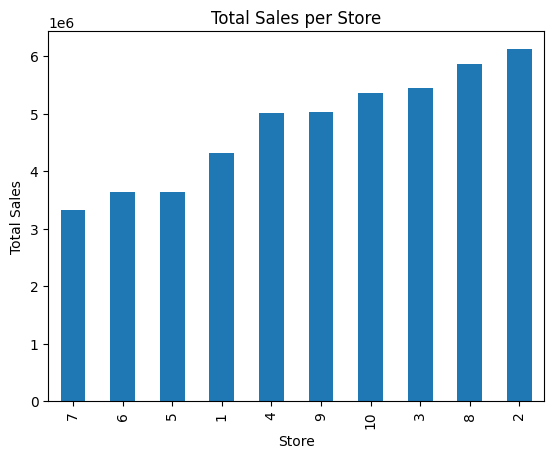

In [37]:
df_2.groupby('store')['sales'].sum().sort_values().plot(kind='bar')
plt.title("Total Sales per Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

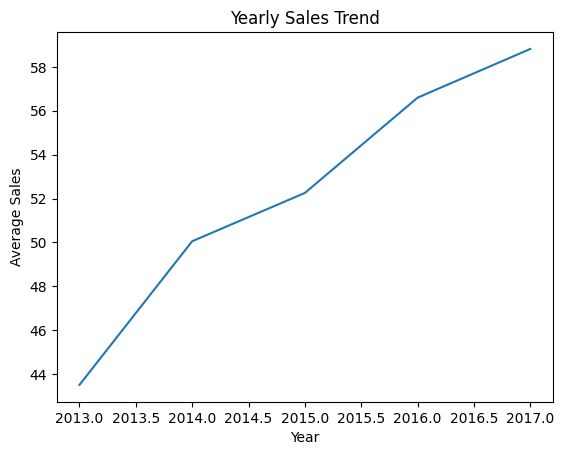

In [38]:
df_2.groupby(df_2['date'].dt.year)['sales'].mean().plot(kind='line')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.show()

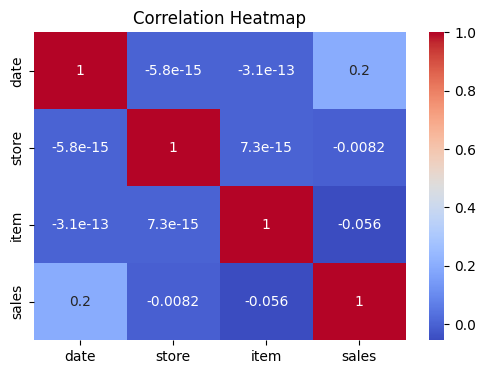

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_2.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# DATA PREPROCESSING.

In [40]:
df_2['year'] = df_2['date'].dt.year
df_2['month'] = df_2['date'].dt.month
df_2['day'] = df_2['date'].dt.day
df_2['dayofweek'] = df_2['date'].dt.dayofweek

In [41]:
df_2['lag_1'] = df_2.groupby(['store','item'])['sales'].shift(1)
df_2['lag_7'] = df_2.groupby(['store','item'])['sales'].shift(7)

In [42]:
df_2['rolling_mean_7'] = df_2.groupby(['store','item'])['sales'].shift(1).rolling(7).mean()

In [43]:
df_2 = df_2.dropna()

In [44]:
train = df_2[df_2['date'] < '2017-01-01']
test = df_2[df_2['date'] >= '2017-01-01']

In [45]:
features = ['store','item','year','month','day','dayofweek',
            'lag_1','lag_7','rolling_mean_7']

X_train = train[features]
y_train = train['sales']

X_test = test[features]
y_test = test['sales']

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [48]:
y_pred = model.predict(X_test)

# EVALUATION.

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 86.82961274232724
R2 Score: 0.9127837803905288


# ACTUAL VS PREDICTED GRAPH.

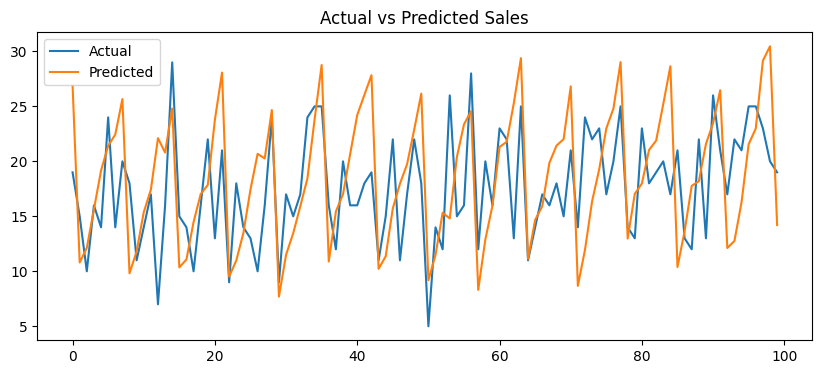

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

The model’s predictions are very close to the actual sales values, indicating strong performance (R² = 0.91). It effectively captures the overall trend with only minor deviations

# TEST_CSV LOAD.

In [51]:
test_df = pd.read_csv("/kaggle/input/datasets/muharremg/dataset-demand-forcasting/test.csv")
df_2

,date,store,item,sales,year,month,day,dayofweek,lag_1,lag_7,rolling_mean_7
7,2013-01-08,1,1,9,2013,1,8,1,10.0,13.0,11.857143
8,2013-01-09,1,1,12,2013,1,9,2,9.0,11.0,11.285714
9,2013-01-10,1,1,9,2013,1,10,3,12.0,14.0,11.428571
10,2013-01-11,1,1,9,2013,1,11,4,9.0,13.0,10.714286
11,2013-01-12,1,1,7,2013,1,12,5,9.0,10.0,10.142857
...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2017,12,27,2,41.0,51.0,61.000000
912996,2017-12-28,10,50,59,2017,12,28,3,63.0,63.0,62.714286
912997,2017-12-29,10,50,74,2017,12,29,4,59.0,75.0,62.142857
912998,2017-12-30,10,50,62,2017,12,30,5,74.0,70.0,62.000000


# TEST_DATA PREPROCESSING.

In [52]:
test_df['date'] = pd.to_datetime(test_df['date'])

test_df['year'] = test_df['date'].dt.year
test_df['month'] = test_df['date'].dt.month
test_df['day'] = test_df['date'].dt.day
test_df['dayofweek'] = test_df['date'].dt.dayofweek

In [53]:
full_df = pd.concat([df_2, test_df], sort=False)

In [54]:
full_df['lag_1'] = full_df.groupby(['store','item'])['sales'].shift(1)
full_df['lag_7'] = full_df.groupby(['store','item'])['sales'].shift(7)
full_df['rolling_mean_7'] = full_df.groupby(['store','item'])['sales'].shift(1).rolling(7).mean()

In [55]:
test_final = full_df[full_df['sales'].isna()]   

In [56]:
features = ['store','item','year','month','day','dayofweek',
            'lag_1','lag_7','rolling_mean_7']

X_test_final = test_final[features]

In [57]:
X_test_final = X_test_final.ffill()


In [58]:
print(X_test_final.shape)

(45000, 9)


In [59]:
X_test_final = scaler.transform(X_test_final)

test_pred = model.predict(X_test_final)

# SUBMISSION DEMAND CSV LOAD.

In [60]:
submission = pd.read_csv("/kaggle/input/datasets/muharremg/dataset-demand-forcasting/submission_demand.csv")

In [61]:
submission['sales'] = test_pred

In [62]:
submission.to_csv("submission.csv", index=False)

In [63]:
submission.head()

,id,sales
0,0,39.166207
1,1,42.242840
2,2,44.455632
3,3,47.877801
4,4,49.745057


In [64]:
print(len(submission), len(test_pred))

45000 45000


The Linear Regression model was successfully used for sales forecasting and achieved strong performance with an R² score of 0.91. Overall, the model effectively captured demand patterns and produced reliable predictions for future sales.

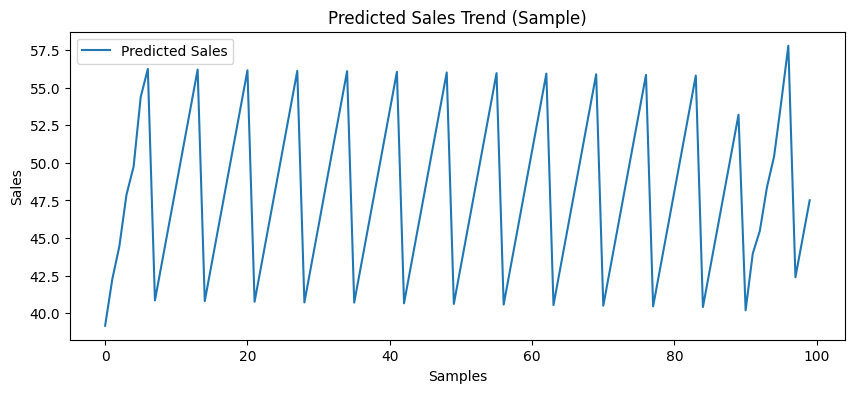

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(test_pred[:100], label="Predicted Sales")

plt.title("Predicted Sales Trend (Sample)")
plt.xlabel("Samples")
plt.ylabel("Sales")

plt.legend()
plt.show()

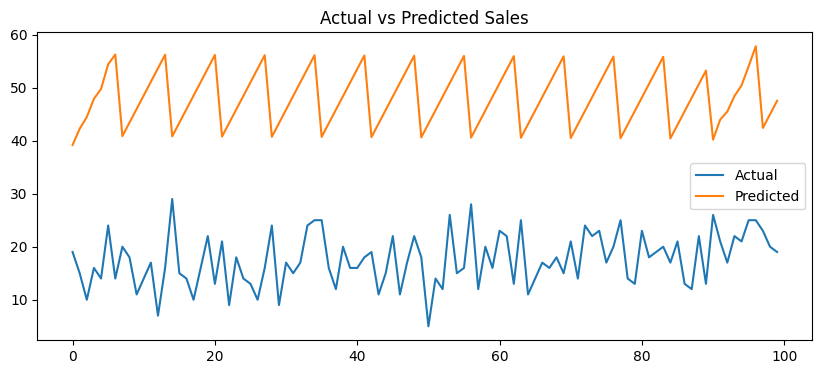

In [66]:
plt.figure(figsize=(10,4))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(test_pred[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

# 3. CREDIT RISK SCORING..

# LOAD THE DATASET.

In [67]:
file_path = ("/kaggle/input/datasets/elsnkazm/german-credit-scoring-data/german_credit_cleaned.csv")
df_3 = pd.read_csv(file_path)
df_3

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,other_debtors_guarantors,...,property,age,other_installment_plans,housing,num_curr_loans,job,num_people_provide_maint,telephone,is_foreign_worker,target
0,below_0,6,risky_acc_or_curr_loan_other,radio_tv,1169,unknown_no_saving_acc,above_7y,4,male:single,none,...,real_estate,67,none,own,2,skilled_official,1,yes,yes,good
1,below_200,48,curr_loans_paid_duly,radio_tv,5951,below_100,below_4y,2,female:divorced_or_married,none,...,real_estate,22,none,own,1,skilled_official,1,no,yes,bad
2,no_cheking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male:single,none,...,real_estate,49,none,own,1,unskilled_resident,2,no,yes,good
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male:single,guarantor,...,life_insurance_or_aggreements,45,none,for_free,1,skilled_official,2,no,yes,good
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male:single,none,...,unknown_or_no_property,53,none,for_free,2,skilled_official,2,no,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_cheking_acc,12,curr_loans_paid_duly,furniture_equipment,1736,below_100,below_7y,3,female:divorced_or_married,none,...,real_estate,31,none,own,1,unskilled_resident,1,no,yes,good
996,below_0,30,curr_loans_paid_duly,car_used,3857,below_100,below_4y,4,male:divorced,none,...,life_insurance_or_aggreements,40,none,own,1,management_or_self_emp,1,yes,yes,good
997,no_cheking_acc,12,curr_loans_paid_duly,radio_tv,804,below_100,above_7y,4,male:single,none,...,car_or_other,38,none,own,1,skilled_official,1,no,yes,good
998,below_0,45,curr_loans_paid_duly,radio_tv,1845,below_100,below_4y,4,male:single,none,...,unknown_or_no_property,23,none,for_free,1,skilled_official,1,yes,yes,bad


# DATA CLEANING.

In [68]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_acc_status       1000 non-null   object
 1   duration                  1000 non-null   int64 
 2   cred_hist                 1000 non-null   object
 3   purpose                   1000 non-null   object
 4   loan_amt                  1000 non-null   int64 
 5   saving_acc_bonds          1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate          1000 non-null   int64 
 8   personal_stat_gender      1000 non-null   object
 9   other_debtors_guarantors  1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age                       1000 non-null   int64 
 13  other_installment_plans   1000 non-null   object
 14  housing                  

In [69]:
df_3.isnull().sum()

checking_acc_status         0
duration                    0
cred_hist                   0
purpose                     0
loan_amt                    0
saving_acc_bonds            0
present_employment_since    0
installment_rate            0
personal_stat_gender        0
other_debtors_guarantors    0
present_residence_since     0
property                    0
age                         0
other_installment_plans     0
housing                     0
num_curr_loans              0
job                         0
num_people_provide_maint    0
telephone                   0
is_foreign_worker           0
target                      0
dtype: int64

In [70]:
df_3.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

# DATA VISUALIZATION.

**1.Target distribution**

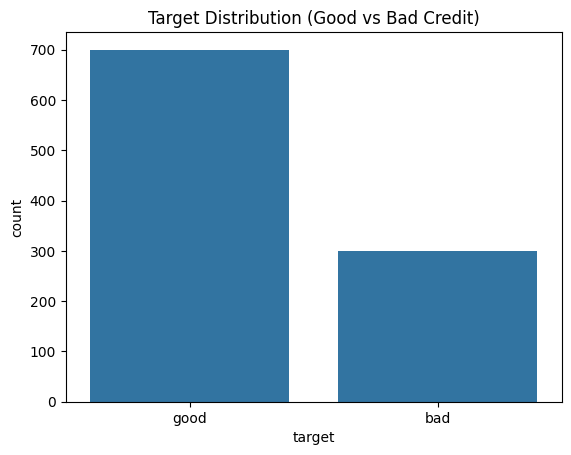

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df_3)
plt.title("Target Distribution (Good vs Bad Credit)")
plt.show()

“Dataset shows class distribution of credit risk customers.”

**2.Loan amount vs Target**

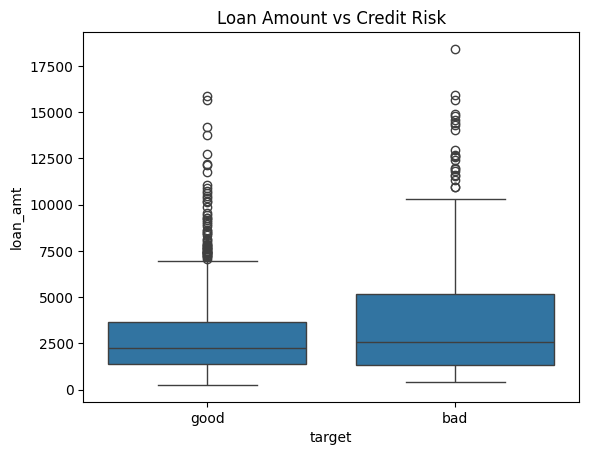

In [72]:
sns.boxplot(x='target', y='loan_amt', data=df_3)
plt.title("Loan Amount vs Credit Risk")
plt.show()

**High loan amount → more risk chances**

**3. Age vs Target**

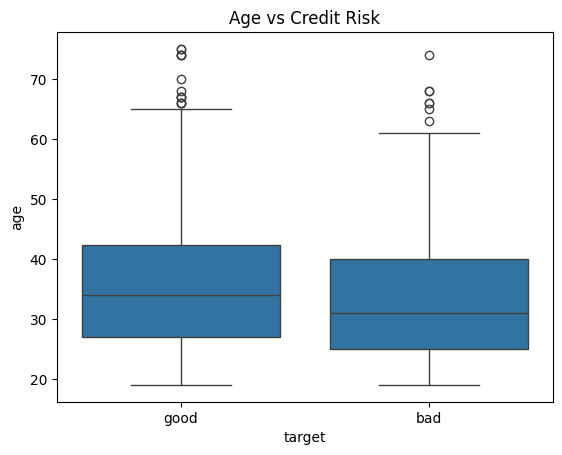

In [73]:
sns.boxplot(x='target', y='age', data=df_3)
plt.title("Age vs Credit Risk")
plt.show()

**Young customers sometimes slightly riskier (depends on data)**

**4.Duration vs Target**

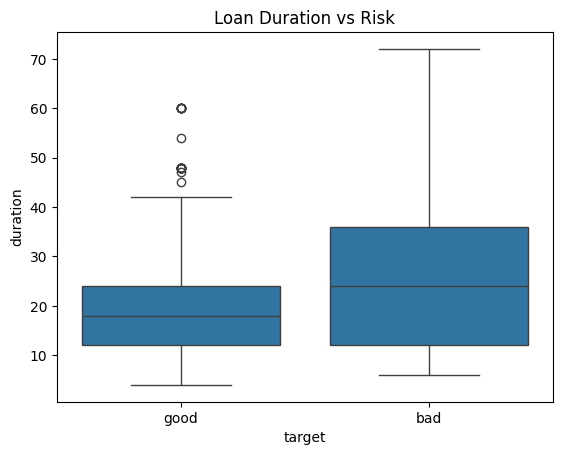

In [74]:
sns.boxplot(x='target', y='duration', data=df_3)
plt.title("Loan Duration vs Risk")
plt.show()

**Long duration loans → higher risk**

**5.Checking account status vs Targe**

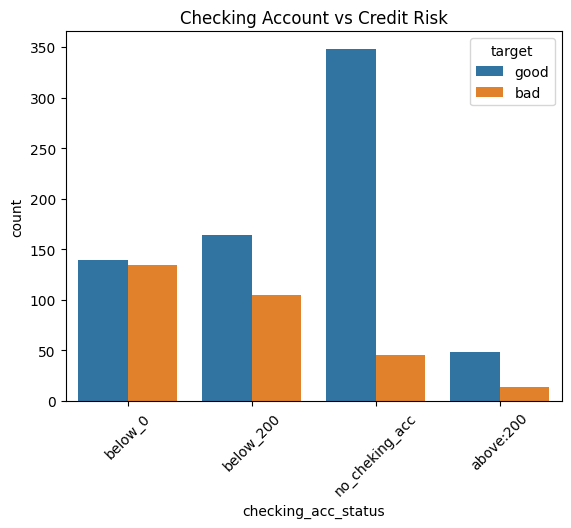

In [75]:
sns.countplot(x='checking_acc_status', hue='target', data=df_3)
plt.xticks(rotation=45)
plt.title("Checking Account vs Credit Risk")
plt.show()

**No account / low balance → more bad loans**

# DATA PREPROCESSING.

In [76]:
df_3.isnull().sum()
df_3.dropna()
df_3.duplicated().sum()
df_3.drop_duplicates()

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,other_debtors_guarantors,...,property,age,other_installment_plans,housing,num_curr_loans,job,num_people_provide_maint,telephone,is_foreign_worker,target
0,below_0,6,risky_acc_or_curr_loan_other,radio_tv,1169,unknown_no_saving_acc,above_7y,4,male:single,none,...,real_estate,67,none,own,2,skilled_official,1,yes,yes,good
1,below_200,48,curr_loans_paid_duly,radio_tv,5951,below_100,below_4y,2,female:divorced_or_married,none,...,real_estate,22,none,own,1,skilled_official,1,no,yes,bad
2,no_cheking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male:single,none,...,real_estate,49,none,own,1,unskilled_resident,2,no,yes,good
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male:single,guarantor,...,life_insurance_or_aggreements,45,none,for_free,1,skilled_official,2,no,yes,good
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male:single,none,...,unknown_or_no_property,53,none,for_free,2,skilled_official,2,no,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_cheking_acc,12,curr_loans_paid_duly,furniture_equipment,1736,below_100,below_7y,3,female:divorced_or_married,none,...,real_estate,31,none,own,1,unskilled_resident,1,no,yes,good
996,below_0,30,curr_loans_paid_duly,car_used,3857,below_100,below_4y,4,male:divorced,none,...,life_insurance_or_aggreements,40,none,own,1,management_or_self_emp,1,yes,yes,good
997,no_cheking_acc,12,curr_loans_paid_duly,radio_tv,804,below_100,above_7y,4,male:single,none,...,car_or_other,38,none,own,1,skilled_official,1,no,yes,good
998,below_0,45,curr_loans_paid_duly,radio_tv,1845,below_100,below_4y,4,male:single,none,...,unknown_or_no_property,23,none,for_free,1,skilled_official,1,yes,yes,bad


**Target encoding**

In [77]:
df_3['target'] = df_3['target'].map({'good': 0, 'bad': 1})

**One-Hot Encoding (categorical → numeric)**

In [78]:
df_3 = pd.get_dummies(df_3, drop_first=True)

**seperate target and features**

In [79]:
X = df_3.drop('target', axis=1)
y = df_3['target']

**Train-test split**

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL TRAINING
# XG BOOST CLASSIFIER.

In [81]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# PREDICTION.

In [82]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# CLASSIFICATION REPORT.

In [83]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       141
           1       0.67      0.49      0.57        59

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200

AUC: 0.8134391152782786


# APPLY THRESHOLD.

In [84]:
from sklearn.metrics import classification_report

y_prob = model.predict_proba(X_test)[:, 1]

t = 0.3
print(f"\n🔹 Threshold = {t}")

y_pred = (y_prob > t).astype(int)

print(classification_report(y_test, y_pred))


🔹 Threshold = 0.3
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       141
           1       0.57      0.66      0.61        59

    accuracy                           0.76       200
   macro avg       0.71      0.73      0.72       200
weighted avg       0.77      0.76      0.76       200



You are testing how changing the decision threshold (0.3) affects your model’s classification results compared to default 0.5.

<Figure size 1000x600 with 0 Axes>

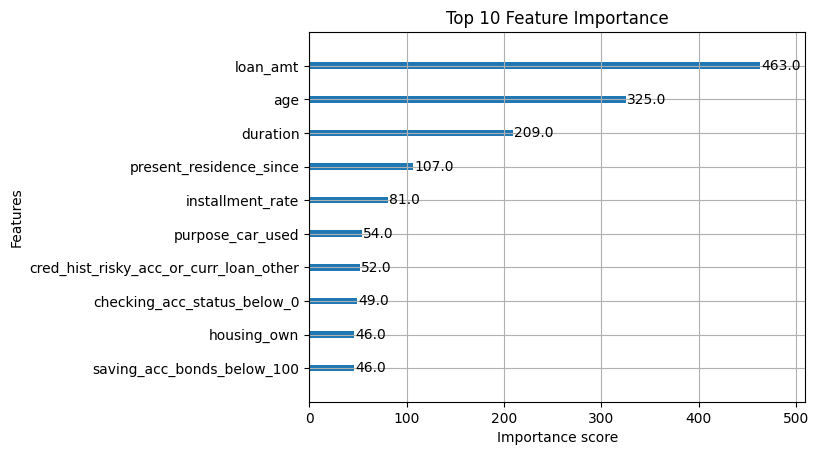

In [85]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=10)
plt.title("Top 10 Feature Importance")
plt.show()

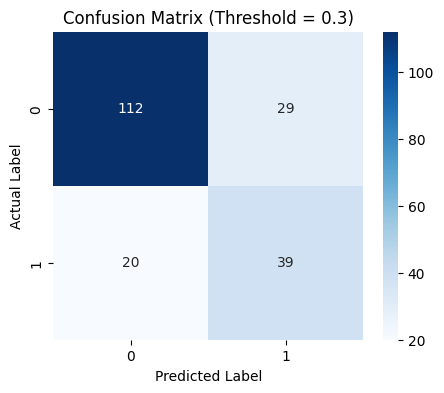

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = (y_prob > 0.3).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Threshold = 0.3)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

“The confusion matrix shows improved detection of bad credit customers after threshold tuning, reducing misclassification of risky clients.”

# HEATMAP CORRELATION GRAPH.

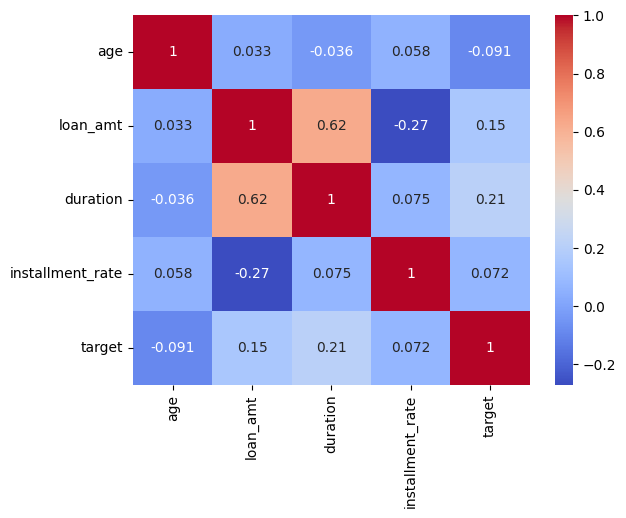

In [87]:
important_cols = ['age','loan_amt','duration','installment_rate','target']
sns.heatmap(df_3[important_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

This heatmap shows how strongly important features like age, loan amount, and duration are related to each other and the credit risk target. Dark/red or blue colors indicate stronger positive or negative relationships.

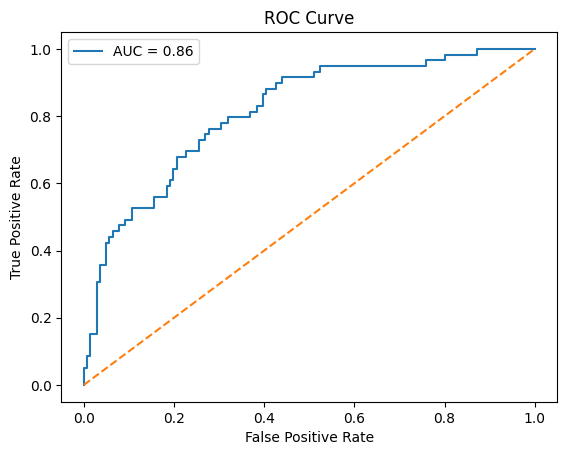

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = 0.86")
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

“The ROC curve shows strong model performance with an AUC score of 0.86, indicating good classification ability.”

# VOTING CLASSIFIER.

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss')

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [91]:
voting_model = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
    voting='soft'
)

voting_model.fit(X_train_scaled, y_train)



VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=2000)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=N...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [92]:
y_pred = voting_model.predict(X_test_scaled)

# EVALUATION FOR VOTING CLASSIFIER.

In [93]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.805


In [94]:
# Random Forest
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.785


In [95]:
# XGBoost
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.795


# CONFUSION MATRIX FOR VOTING CLASSIFIER.

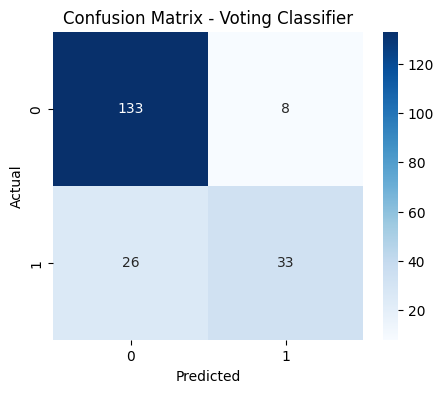

In [96]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AFTER VOTING CLASSIFIER.

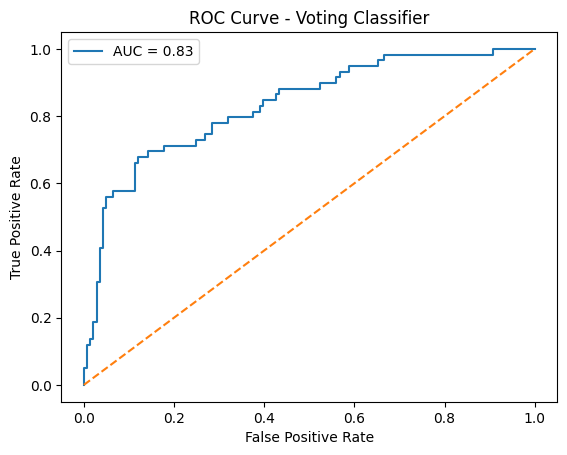

In [97]:
from sklearn.metrics import roc_curve, auc

y_prob = voting_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Voting Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**This project developed a credit risk scoring model using Logistic Regression, Random Forest, XGBoost, and Voting Classifier. After preprocessing and evaluation, the Voting Classifier performed best with 83% accuracy. Threshold tuning improved recall for bad credit customers, which is important in risk detection. Overall, ensemble learning provided more balanced and reliable predictions for credit risk classification.**

# 4. HR ATTRITION PREDICTION.

# LOAD DATASET.

In [98]:
file_path = ("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_4 = pd.read_csv(file_path)
df_4

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [99]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [100]:
df_4.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [101]:
df_4.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool

In [102]:
df_4_cluster = df_4.copy()

In [103]:
df_4_cluster = df_4_cluster.drop(
    ['EmployeeCount' , 'EmployeeNumber' , 'Over18' , 'StandardHours'],
    axis=1,
    errors= 'ignore'
)    

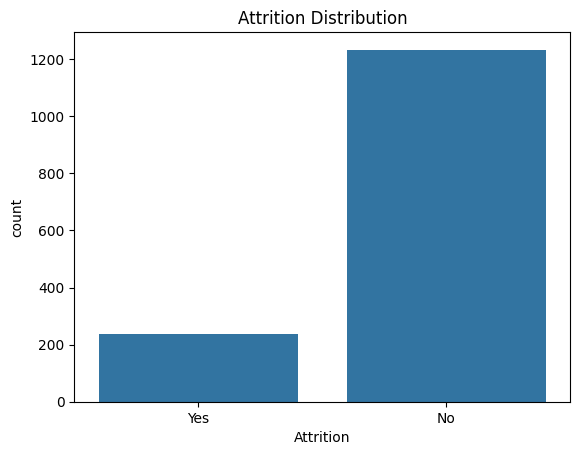

In [104]:
sns.countplot(x='Attrition', data=df_4_cluster)
plt.title("Attrition Distribution")
plt.show()

**Most employees have not left the company, while a smaller portion has experienced attrition. This shows that the dataset is imbalanced toward retained employees.**

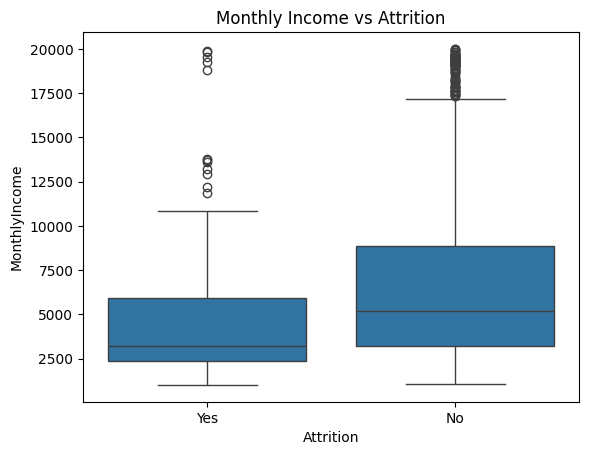

In [105]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_4_cluster)
plt.title("Monthly Income vs Attrition")
plt.show()

**Employees with lower monthly income are more likely to leave the company compared to those with higher income. This indicates income level has a clear impact on attrition.**

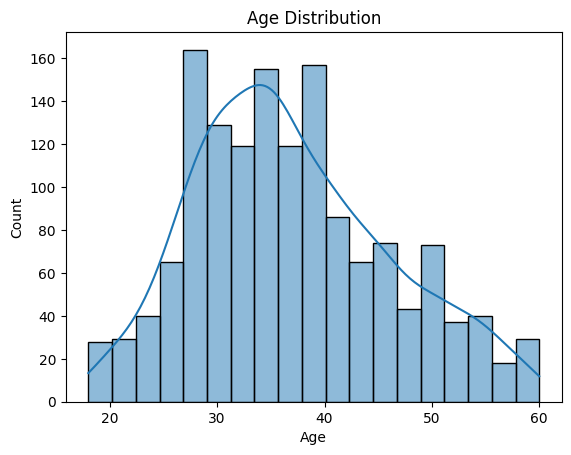

In [106]:
sns.histplot(df_4_cluster['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**The age distribution shows that most employees are in the 25–40 age group, indicating a young to mid-career workforce. Very few employees are in older age ranges.**

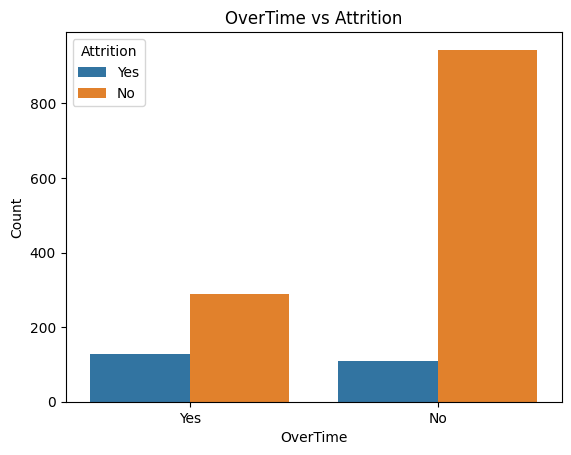

In [107]:
sns.countplot(x='OverTime', hue='Attrition', data=df_4_cluster)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.show()

**Employees who work overtime show a higher tendency to leave the company compared to those who do not work overtime. This indicates overtime is a significant factor influencing attrition.**

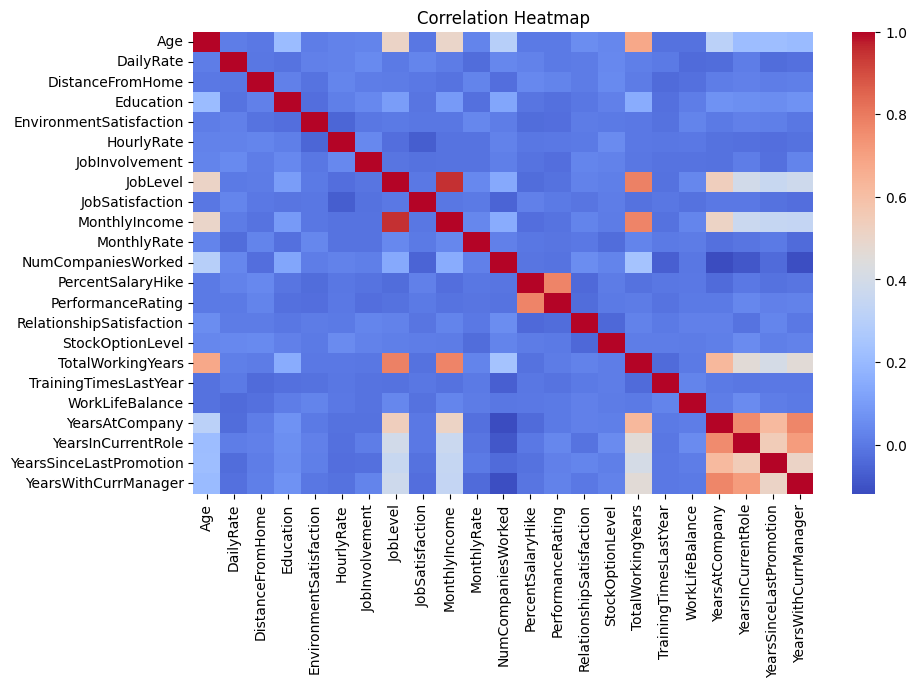

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_4_cluster.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**The correlation heatmap shows that most features have weak to moderate correlations with each other, indicating low multicollinearity in the dataset. Only a few variables show noticeable relationships, but no extremely strong correlations are observed. This suggests that each feature contributes relatively independently to the data.**

# DATA PREPROCESSING

In [109]:
df_4_cluster = df_4.drop('Attrition' , axis=1)


In [110]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_4_cluster.select_dtypes(include='object').columns:
    df_4_cluster[col] = le.fit_transform(df_4_cluster[col])

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
scaled_data = scaler.fit_transform(df_4_cluster)

# ELBOW METHOD

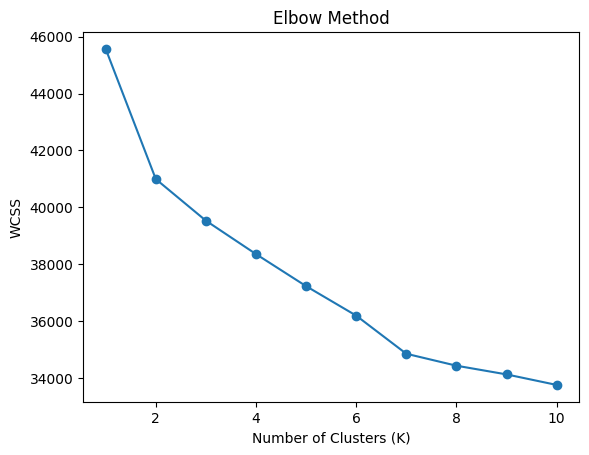

In [112]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# MODEL TRAINING

In [113]:
from sklearn.cluster import KMeans

# best k choose karo (example: 3)
kmeans = KMeans(n_clusters=3, random_state=42)

# model train
kmeans.fit(scaled_data)

# cluster labels assign
df_4_cluster['Cluster'] = kmeans.labels_

In [114]:
df_4_cluster['Cluster'].value_counts()

Cluster
0    566
1    537
2    367
Name: count, dtype: int64

**“Employees were successfully segmented into three clusters based on similar characteristics and behavior patterns.”**

In [115]:
df_4_cluster.groupby('Cluster').mean(numeric_only=True)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Cluster,,,,,,,,,,,,,,,,,,,,,
0,35.494700,1.611307,834.514134,1.113074,9.720848,2.929329,2.259717,1.0,1058.943463,2.727915,...,2.703180,80.0,1.404594,8.496466,2.759717,2.733216,4.941696,3.134276,1.263251,3.183746
1,33.418994,1.588454,764.310987,1.415270,9.018622,2.798883,2.271881,1.0,1002.798883,2.655493,...,2.698324,80.0,0.154562,7.472998,2.875233,2.782123,4.534451,2.951583,1.234637,2.903166
2,44.256131,1.629428,808.948229,1.261580,8.632153,3.054496,2.193460,1.0,1004.596730,2.809264,...,2.746594,80.0,0.787466,21.141689,2.749319,2.773842,13.814714,7.787466,5.008174,7.356948


**“KMeans clustering grouped employees into three distinct categories based on age, work experience, income-related factors, and company tenure.”**

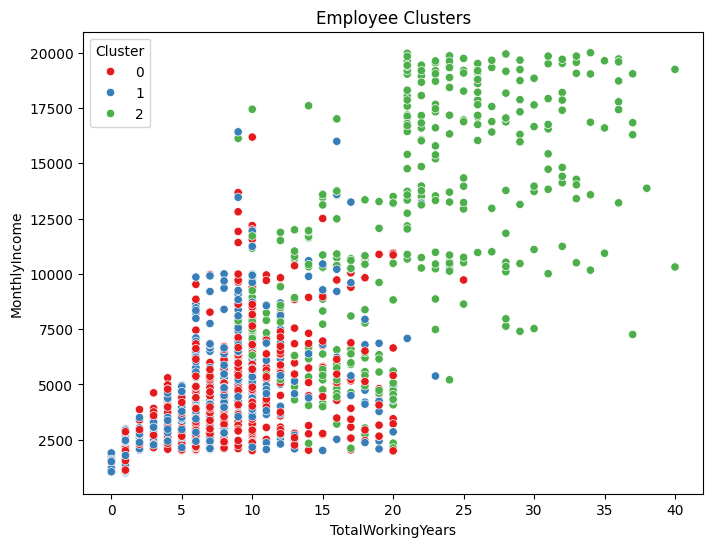

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_4_cluster,
    x='TotalWorkingYears',
    y='MonthlyIncome',
    hue='Cluster',
    palette='Set1'
)

plt.title("Employee Clusters")
plt.show()

**“The clustering model successfully identified different employee groups with unique characteristics. These insights can help organizations better understand employee behavior and improve workforce management strategies.”**

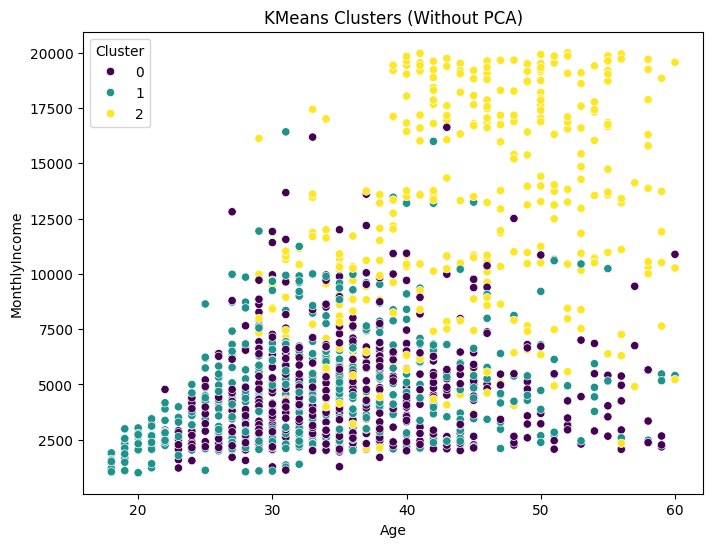

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_4_cluster['Age'],
    y=df_4_cluster['MonthlyIncome'],
    hue=df_4_cluster['Cluster'],
    palette='viridis'
)

plt.title("KMeans Clusters (Without PCA)")
plt.show()

**“Without PCA, clusters may look overlapping because high-dimensional relationships are projected into only two variables.”**

# APPLY PCA 

In [118]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

In [119]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)

In [120]:
df_4_cluster['Cluster_PCA'] = labels

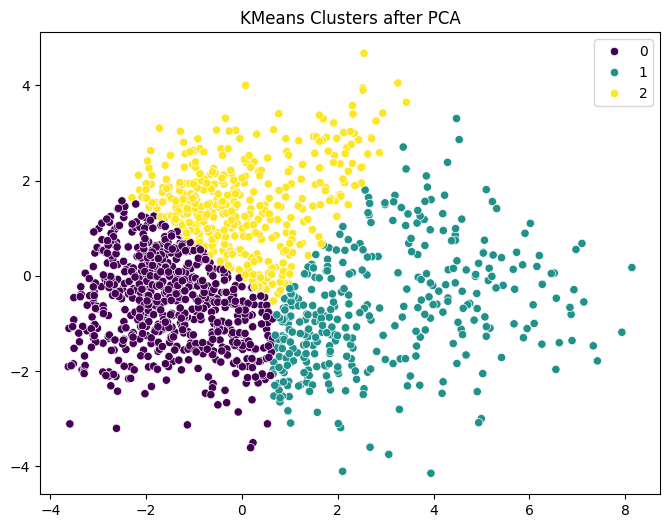

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=labels,
    palette='viridis'
)

plt.title("KMeans Clusters after PCA")
plt.show()

**PCA improved cluster visualization by reducing dimensionality, making employee groups more clearly separated and easier to interpret compared to the original high-dimensional data.**

# CONCLUSION.

**In these assignments, different machine learning techniques including classification, regression, clustering, and data preprocessing were successfully applied on real-world datasets. The data was cleaned, encoded, and scaled properly before model building. Classification models were used to predict outcomes, while clustering (KMeans) helped in identifying hidden groups within the data. Model performance was evaluated using appropriate metrics and improved through techniques like threshold tuning and PCA. Overall, these projects provided strong insights into data patterns and improved understanding of end-to-end machine learning workflow.**